# [LAB 07 추론통계] 3. 단일표본 T-Test

## 01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import my_stats, my_plot
from pandas import DataFrame

# 단일표본 T-Test를 위한 라이브러리 
from scipy.stats import ttest_1samp, wilcoxon

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## #02. 예제(1) - 강아지 체온 변화 

### 1. 데이터 가져오기 

In [2]:
df1 = load_data('dog_temperature')
df1.head()

📚 강아지 25마리의 체온을 측정한 데이터 (출처: 방송통신대학교 통계학개론)


,체온
0,25.800
1,24.600
2,26.100
3,22.900
4,25.100


### 2. 데이터분포 시각화 

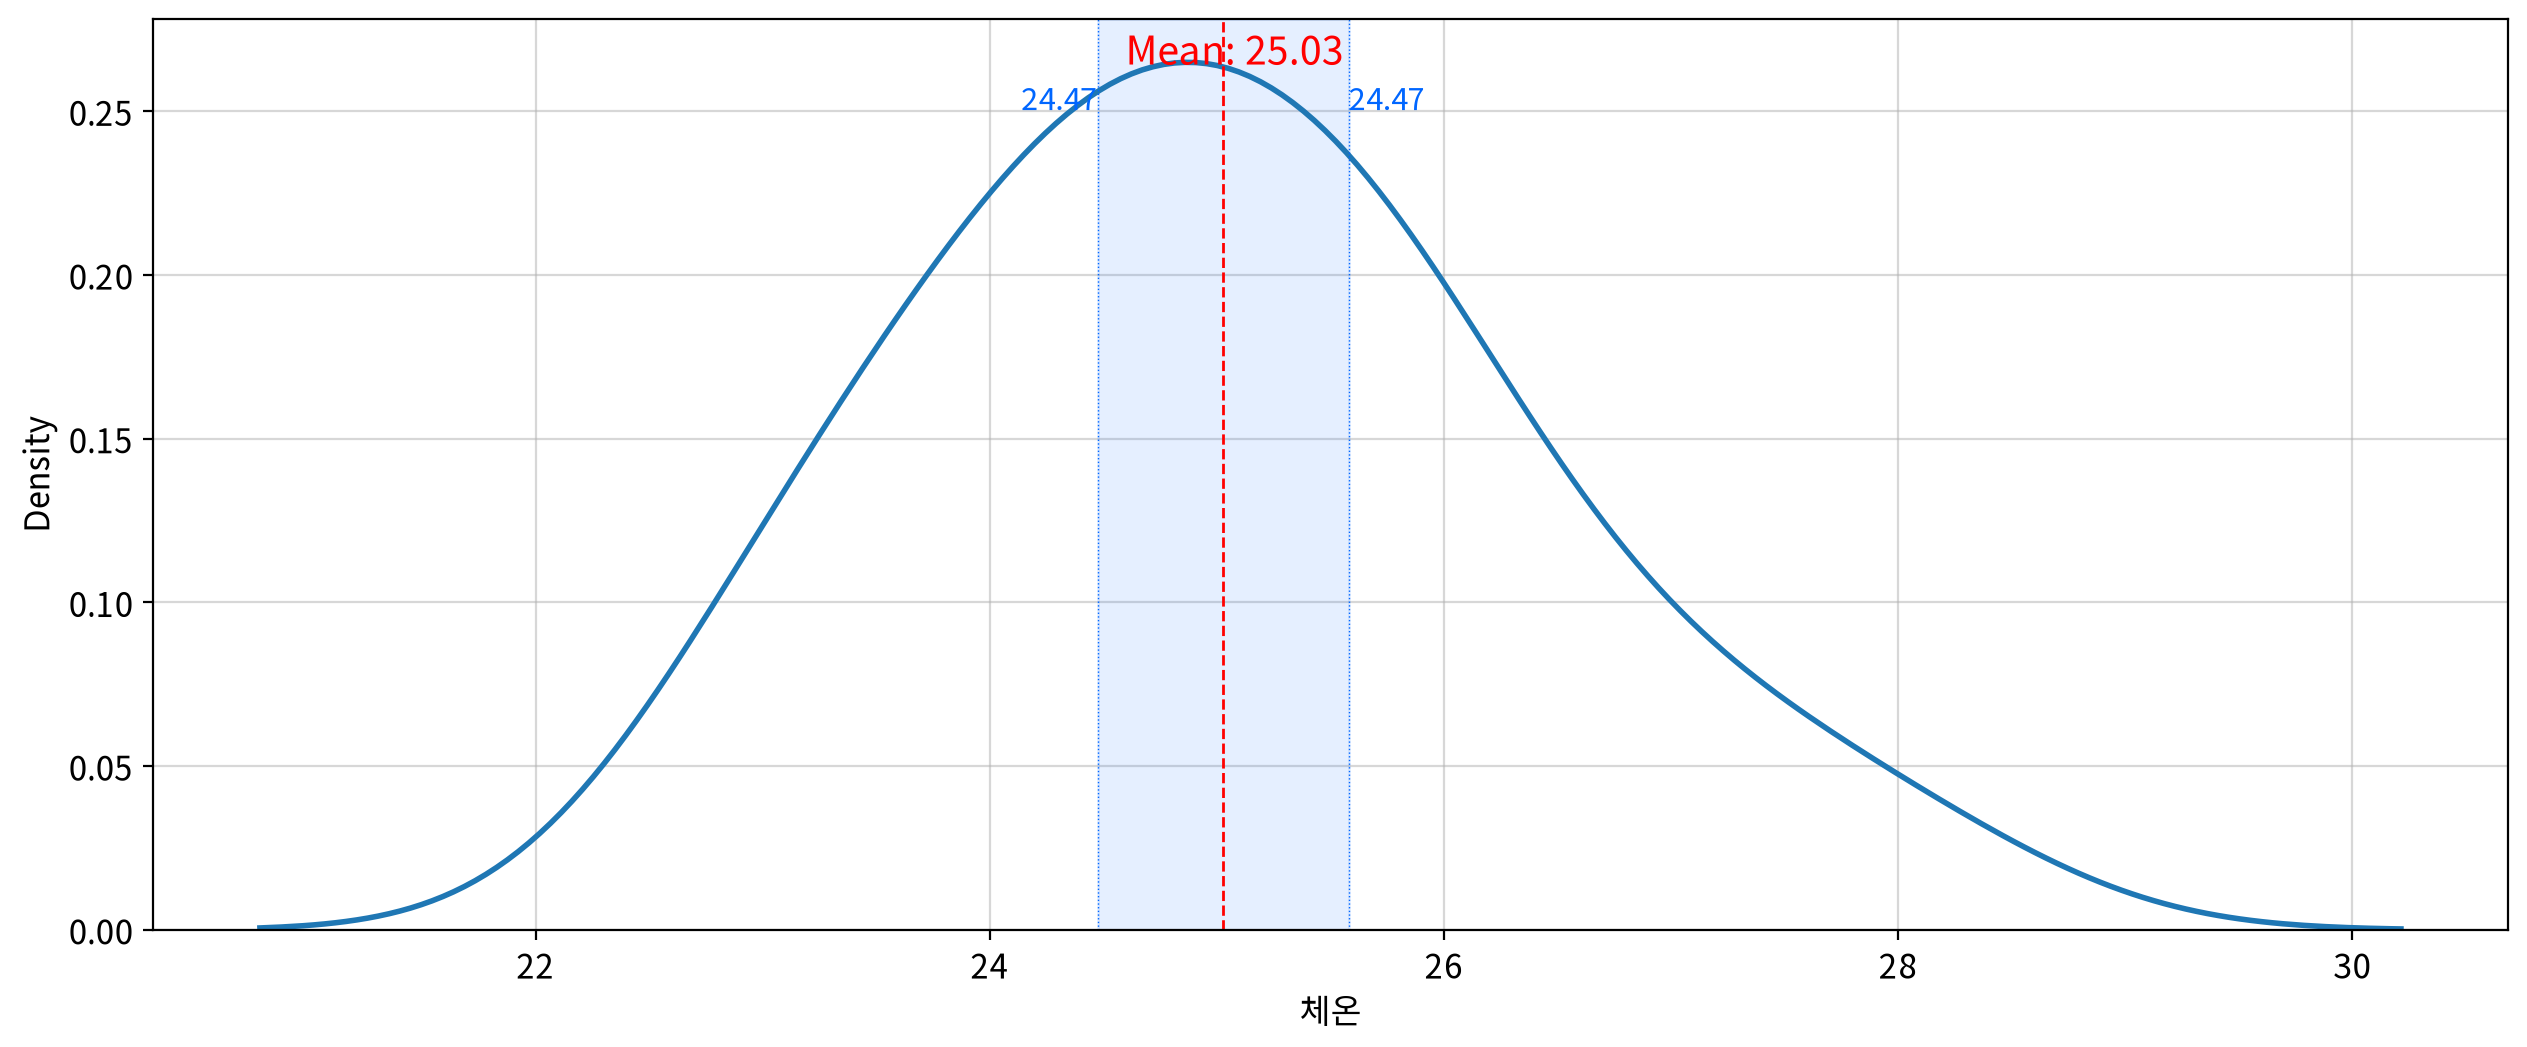

In [3]:
my_plot.kdeplot(df1, x='체온', meanline=True, clevel=0.95)

### 3. 가설검정의 가정 확인 

In [4]:
my_stats.test_assumptions(df1, columns=['체온'])

,test,statistic,p-value,result
field,,,,
체온,normaltest,0.819,0.664,True


### 4. One Sample T-Test 양측검정 

In [5]:
popmean = 24.3      # 비교 기준값을 변수로 저장 
alternative = "two-sided" # 'two-sided' , 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-ststistic: {s:.4f}, p-value: {p:.4f}")

t-ststistic: 2.7128, p-value: 0.0121


### 5. One Sample T - Test 좌측 단측 검정 

In [6]:
popmean = 24.3 # 비교 기준값을 변수로 저장 
alternative = "less"        # 'two-sided', 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: 2.7128, p-value: 0.9939


### 6. One Sample T-Test 우측 단측 검정 

In [7]:
popmean = 24.3 # 비교 기준값을 변수로 저장 
alternative = "greater"        # 'two-sided', 'less', 'greater'
s, p = ttest_1samp(df1['체온'], popmean, alternative=alternative)
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")

t-statistic: 2.7128, p-value: 0.0061


## #03. 예제(2) - 생명보험 가입 금액 평균 비교 

### 1. 데이터 가져오기 

In [8]:
df2 = load_data("insur")
df2.head()

📚 어느 보험회사에서 한해 동안 모집한 가입원들에 대한 가입 정보 (출처: 방송통신대학교 통계학개론)

    field     description
--  --------  ------------------------------------------------------
 0  직업      1=육체노동, 2=정신노동(직상인), 3=자영업
 1  교육수준  1=초등학교 이하, 2=중졸 및 고졸, 3=대졸, 4=대학원 졸업
 2  성별      1=남자, 2=여자
 3  나이      숫자
 4  가입금액  단위=천만원
 5  월수입    단위=만원



,직업,교육수준,성별,나이,가입금액,월수입
0,1,2,1,35,15.000,100
1,2,3,1,40,10.000,150
2,2,3,2,36,8.000,120
3,3,4,2,38,12.000,140
4,1,1,1,45,10.000,150


### 2. 데이터분포 시각화 

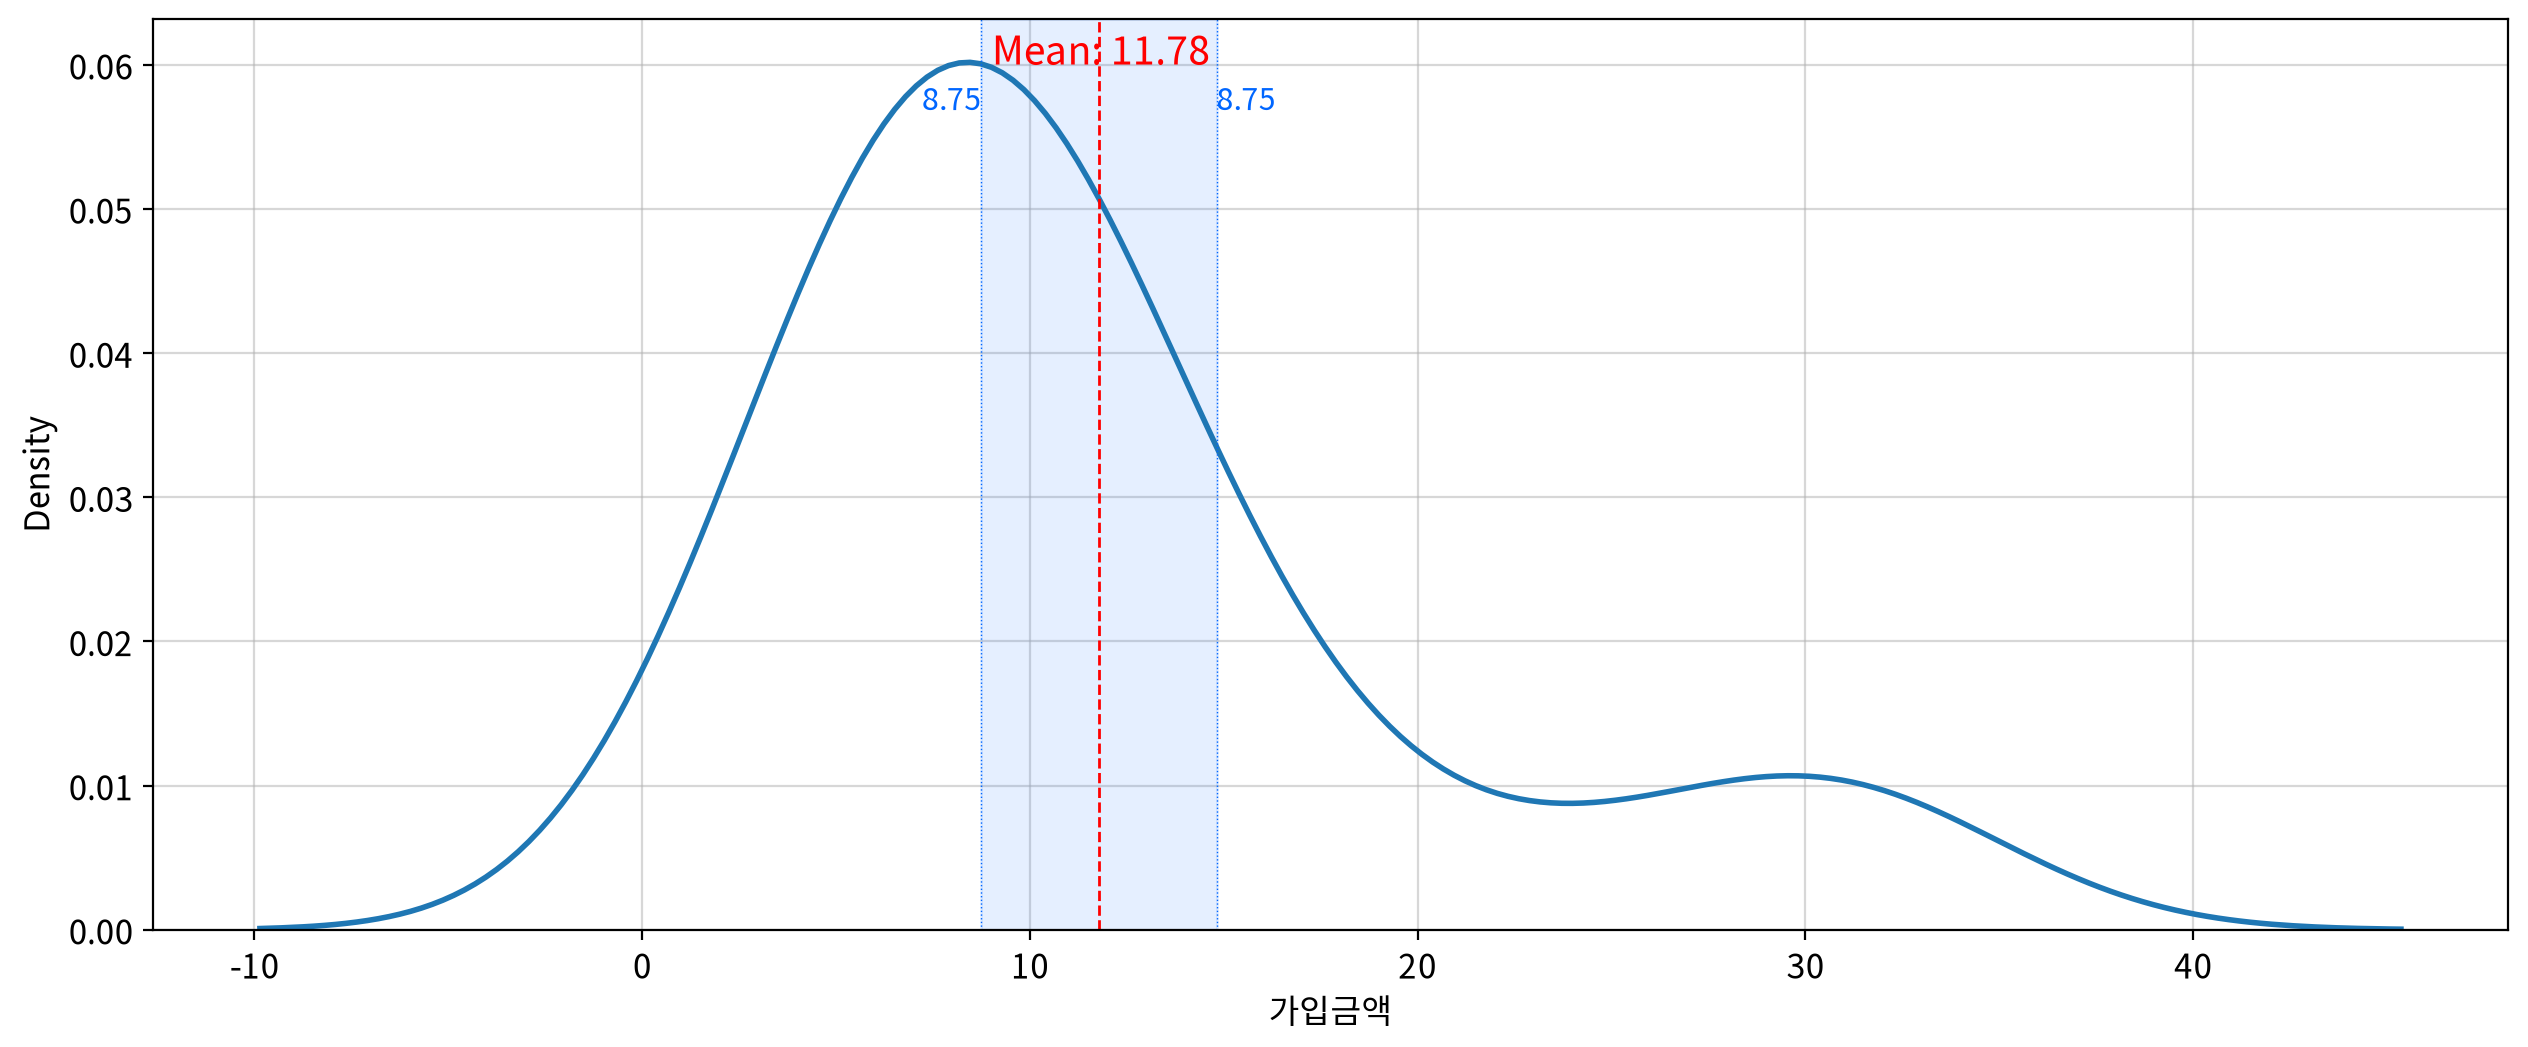

In [9]:
my_plot.kdeplot(df2, x='가입금액', meanline=True, clevel=0.95)

### 3. 데이터의 정규성 검정 

In [10]:
my_stats.test_assumptions(df2, columns='가입금액')

,test,statistic,p-value,result
field,,,,
가입금액,normaltest,11.438,0.003,False


### 4. Willcoxon Signed Rank Test 양측검정 

In [11]:
# 천만원 단위에서 1억원
target_value = 10.0

# 기준값을 뺀 차이에 대한 Wilcoxon 부호순위 검정 
s, p = wilcoxon(df2['가입금액'] - target_value) 
print(f"Wilcoxon statistic: {s:.4f}, p-value:{p:.4f}")

Wilcoxon statistic: 183.5000, p-value:0.8948


### 5. Wilcoxon Signed Rank Test 좌측 단측 검정 

In [12]:
s, p = wilcoxon(df2['가입금액'] - target_value, alternative='less')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 194.5000, p-value: 0.5526


### 6. Wilcoxon Signed Rank Test 우측 단측검정

In [13]:
s, p = wilcoxon(df2['가입금액'] - target_value, alternative='greater')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 194.5000, p-value: 0.4474


In [14]:
import numpy as np
print(np.__version__)

2.4.6


## #04. 모듈기능 확인 

### 1. 강아지 체온 변화 

In [15]:
my_stats.test_1sample(df1, column='체온', popmean=24.3)

statistic  p-value  significant    result
test              alternative                                           
One-sample t-test two-sided        2.713    0.012         True  μ ≠ 24.3
                  less             2.713    0.994        False  μ ≥ 24.3
                  greater          2.713    0.006         True  μ > 24.3

### 2. 생명보험 가입 평균 금액 비교 

In [16]:
my_stats.test_1sample(df2, column='가입금액', popmean=10)

statistic  p-value  significant  result
test                 alternative                                         
Wilcoxon signed-rank two-sided      183.500    0.895        False  μ = 10
                     less           194.500    0.553        False  μ ≥ 10
                     greater        194.500    0.447        False  μ ≤ 10

## #01 연습문제 

In [17]:
origin = load_data('bread')
origin.head()

📚 매일 아침 동네 빵집에서 식빵을 구입해 무게를 기록한 데이터


,무게
0,482
1,479
2,485
3,474
4,479


### 1. 빵의 평균 무게가 500g과 다른지 확인

| 구분               | 수식            | 내용                                       |
| ------------------ | --------------- | ------------------------------------------ |
| 빵의 평균 무게     | $\mu$           |                                            |
| 귀무가설($H_0$)    | $\mu = 500$     | 빵의 평균 무게가 `500`과 차이가 없다.      |
| 대립가설($H_1$)    | $\mu \neq 500$  | 빵의 평균 무게가 `500`과 차이가 있다.      |

In [18]:
my_stats.test_1sample(origin, column='무게', popmean=500)

statistic  p-value  significant   result
test              alternative                                          
One-sample t-test two-sided      -37.524    0.000         True  μ ≠ 500
                  less           -37.524    0.000         True  μ < 500
                  greater        -37.524    1.000        False  μ ≤ 500

### 2. 결론

검정 결과는 다음과 같다.

- **양측검정(two-sided)**: 검정통계량 `-37.524`, p-value `0.000` → 유의수준 `0.05`보다 작으므로 귀무가설($\mu = 500$)을 기각한다. 즉, **빵의 평균 무게는 500g과 통계적으로 유의한 차이가 있다.**
- **단측검정(less)**: p-value `0.000` → 빵의 평균 무게가 **500g보다 유의하게 작다.**
- **단측검정(greater)**: p-value `1.000` → 500g보다 크다고 볼 근거는 없다.

**답변:** 25일간 측정한 평균 무게 `480g`은 단순한 우연(측정 오차)으로 보기 어렵다. 단일표본 T검정 결과 p-value가 `0.05`보다 훨씬 작아(`< 0.001`) 빵의 평균 무게가 표시값 `500g`보다 통계적으로 유의하게 **가볍다**는 것이 확인되었다. 따라서 베이커리를 찾아가 컴플레인을 제기할 **충분한 통계적 근거가 있다.**